# Hard Drive Failure Prediction — Seagate Interview Prep

**Dataset:** Backblaze Drive Stats, Q1 2026 (https://www.backblaze.com/cloud-storage/resources/hard-drive-test-data)

**License / attribution:** This notebook uses data published by Backblaze under their open data terms.
Per Backblaze's terms: (a) Backblaze is cited as the source of this data, (b) the author accepts
responsibility for how this data and the resulting analysis are used, and (c) the raw data itself
is not redistributed or resold — only derived, filtered subsets and analysis are shared here.


## Framing

This notebook mirrors the warranty/reliability prediction problem described in the Seagate
Corporate Quality job description — predicting drive failure from field telemetry. It walks
through the same problem end-to-end: exploratory data analysis, a survival-analysis framing
(Kaplan-Meier, Cox Proportional Hazards), a practical classification complement for a
risk-scoring dashboard, an honest sequence-model vs. tree-model comparison, and explainability
(SHAP) tying the ML model's reasoning back to the statistical model's hazard ratios.


In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

pd.set_option("display.max_columns", 50)
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")


## Section 1 — EDA

### 1.1 Load and filter to Seagate HDDs

The raw Q1 2026 dataset covers *all* drive manufacturers Backblaze operates (Seagate, WDC,
HGST/Toshiba, and Samsung/Seagate SSDs), across 90 daily CSVs (~339k drive-days each).
We scope down to Seagate for direct relevance to the interviewer, and to cut the data volume
drastically.

**A data-quality finding worth stating explicitly:** Seagate-branded drives appear in this
dataset under two naming schemes — legacy model codes like `ST14000NM001G`, and newer explicit
names like `Seagate BarraCuda SSD ZA500CM10002`. Checking every non-`ST`-prefixed Seagate-branded
model name shows **all of them are SSDs** (BarraCuda/FireCuda/IronWolf SSD kits), not spinning
HDDs. Since this project is about mechanical drive reliability (SMART attributes like reallocated
sectors and pending sectors are HDD wear indicators, not meaningful in the same way for SSDs),
we filter on `model` starting with `"ST"` — which turns out to be exactly "Seagate HDD",
with SSDs excluded for free, no separate SSD-detection logic needed.


In [2]:
DATA_DIR = Path("data/data_Q1_2026/data_Q1_2026")
CACHE_PATH = Path("data/seagate_hdd_q1_2026.parquet")

COLS = [
    "date", "serial_number", "model", "capacity_bytes", "failure",
    "smart_5_raw", "smart_9_raw", "smart_187_raw", "smart_188_raw",
    "smart_197_raw", "smart_198_raw",
]

if CACHE_PATH.exists():
    seagate_hdd = pd.read_parquet(CACHE_PATH)
else:
    frames = []
    for csv_path in sorted(DATA_DIR.glob("*.csv")):
        day = pd.read_csv(csv_path, usecols=COLS)
        day = day[day["model"].str.startswith("ST")]
        frames.append(day)
    seagate_hdd = pd.concat(frames, ignore_index=True)
    seagate_hdd["date"] = pd.to_datetime(seagate_hdd["date"])
    CACHE_PATH.parent.mkdir(exist_ok=True)
    seagate_hdd.to_parquet(CACHE_PATH)

seagate_hdd.shape


(10068229, 11)

### 1.2 True failure rate, before any subsampling

Before we subsample the healthy-drive population down to something fast to run, we record the
*true* failure statistics on the full Seagate-HDD slice. This is the number we'll compare our
subsampled dataset against later, to prove the subsampling preserved the imbalance story rather
than distorting it.

We report this as **Annualized Failure Rate (AFR)** — Backblaze's own convention — rather than
raw drive-day accuracy, since AFR is the industry-standard framing for reliability numbers:

AFR = (failures observed) / (drive-days observed) × 365


In [3]:
n_drive_days = len(seagate_hdd)
n_failures = int(seagate_hdd["failure"].sum())
n_unique_drives = seagate_hdd["serial_number"].nunique()
n_failed_drives = seagate_hdd.loc[seagate_hdd["failure"] == 1, "serial_number"].nunique()

afr = n_failures / n_drive_days * 365

print(f"Drive-days observed:              {n_drive_days:,}")
print(f"Unique Seagate HDDs seen (Q1):     {n_unique_drives:,}")
print(f"Distinct drives that failed:       {n_failed_drives:,}")
print(f"Drive-day failure rate:            {n_failures / n_drive_days:.4%}")
print(f"Annualized Failure Rate (AFR):     {afr:.2%}")


Drive-days observed:              10,068,229
Unique Seagate HDDs seen (Q1):     114,976
Distinct drives that failed:       406
Drive-day failure rate:            0.0040%
Annualized Failure Rate (AFR):     1.47%


### 1.3 Subsample the healthy population (deliberate undersampling)

10M drive-days is slow to iterate on for the survival/ML sections ahead. We keep **every**
drive-day for the 406 drives that failed (their full trajectory matters for survival analysis
and the LSTM sequence model later), and take a **random sample of 8,000** of the ~114,570 drives
that never failed — keeping their full trajectories too.

**This does not preserve the true population failure rate — and it should not.** Keeping 100%% of
the rare failed drives while cutting the healthy population by ~14x mechanically concentrates the
failure signal in the working sample. This is standard **undersampling of the majority class**,
the same imbalance-handling technique Section 4 discusses explicitly for the classifier. We
document both numbers so the true population AFR is never confused with the sample's working
AFR, and so this correction is remembered if the model's output probabilities are ever used as
calibrated real-world risk (they would need re-calibrating against the true 1.47%% base rate).


In [4]:
RNG_SEED = 42
N_HEALTHY_SAMPLE = 8000

failed_serials = seagate_hdd.loc[seagate_hdd["failure"] == 1, "serial_number"].unique()
all_serials = seagate_hdd["serial_number"].unique()
healthy_serials = [s for s in all_serials if s not in set(failed_serials)]

rng = np.random.default_rng(RNG_SEED)
healthy_sample = rng.choice(healthy_serials, size=N_HEALTHY_SAMPLE, replace=False)

keep_serials = set(failed_serials) | set(healthy_sample)
sample_df = seagate_hdd[seagate_hdd["serial_number"].isin(keep_serials)].copy()

full_afr = seagate_hdd["failure"].sum() / len(seagate_hdd) * 365
sample_afr = sample_df["failure"].sum() / len(sample_df) * 365

comparison = pd.DataFrame({
    "population": ["Full Seagate HDD slice", "Subsample (406 failed + 8,000 healthy)"],
    "drive_days": [len(seagate_hdd), len(sample_df)],
    "afr": [full_afr, sample_afr],
})
comparison


,population,drive_days,afr
0,Full Seagate HDD slice,10068229,0.014719
1,"Subsample (406 failed + 8,000 healthy)",718034,0.206383


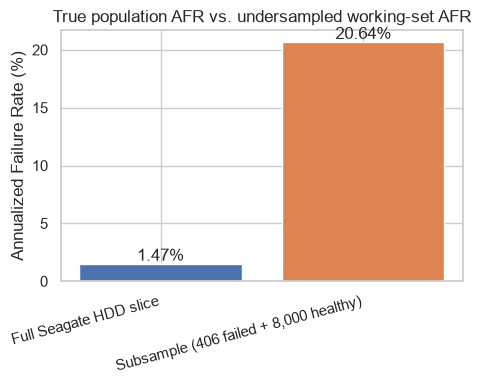

Working-set AFR is 14.0x the true population AFR, by design (majority-class undersampling).


In [5]:
fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(comparison["population"], comparison["afr"] * 100, color=["#4C72B0", "#DD8452"])
ax.set_ylabel("Annualized Failure Rate (%)")
ax.set_title("True population AFR vs. undersampled working-set AFR")
ax.bar_label(bars, fmt="%.2f%%")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.savefig("plots/01_afr_full_vs_sample.png", dpi=120)
plt.show()

fold = comparison.loc[1, "afr"] / comparison.loc[0, "afr"]
print(f"Working-set AFR is {fold:.1f}x the true population AFR, by design (majority-class undersampling).")


### 1.4 Missing SMART data check

Some SMART attributes are legitimately absent for certain drive models/firmware revisions —
this is a hardware/firmware fact, not a data-quality bug. We check missingness on our sampled
drive-days before deciding whether/how to impute.


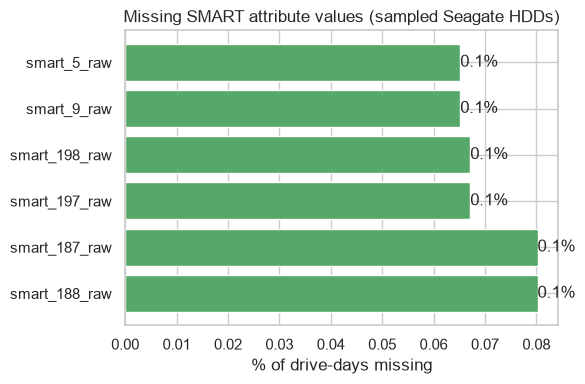

smart_188_raw    0.080219
smart_187_raw    0.080219
smart_197_raw    0.067128
smart_198_raw    0.067128
smart_9_raw      0.065178
smart_5_raw      0.065178
dtype: float64

In [6]:
smart_cols = ["smart_5_raw", "smart_9_raw", "smart_187_raw", "smart_188_raw", "smart_197_raw", "smart_198_raw"]
missing_pct = sample_df[smart_cols].isna().mean().sort_values(ascending=False) * 100

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.barh(missing_pct.index, missing_pct.values, color="#55A868")
ax.set_xlabel("% of drive-days missing")
ax.set_title("Missing SMART attribute values (sampled Seagate HDDs)")
ax.bar_label(bars, fmt="%.1f%%")
plt.tight_layout()
plt.savefig("plots/02_missing_smart_data.png", dpi=120)
plt.show()

missing_pct


### 1.5 Class imbalance, quantified

On a per-drive-day basis, failure is extremely rare. We state this plainly: a model that always
predicts "healthy" would be right almost all the time on drive-days, while being completely
useless for the actual task (catching the drives that are about to fail). This motivates using
PR-AUC / recall / F2 instead of accuracy in Section 4.


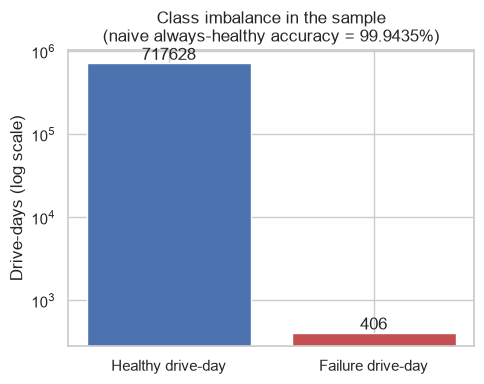

Failure drive-days: 406 of 718,034 (0.0565%)
Naive always-healthy baseline accuracy: 99.9435%


In [7]:
counts = sample_df["failure"].value_counts().rename({0: "Healthy drive-day", 1: "Failure drive-day"})
naive_accuracy = counts["Healthy drive-day"] / counts.sum()

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(counts.index, counts.values, color=["#4C72B0", "#C44E52"])
ax.set_yscale("log")
ax.set_ylabel("Drive-days (log scale)")
ax.set_title(f"Class imbalance in the sample\n(naive always-healthy accuracy = {naive_accuracy:.4%})")
ax.bar_label(bars, fmt="%d")
plt.tight_layout()
plt.savefig("plots/03_class_imbalance.png", dpi=120)
plt.show()

print(f"Failure drive-days: {counts['Failure drive-day']:,} of {counts.sum():,} ({1-naive_accuracy:.4%})")
print(f"Naive always-healthy baseline accuracy: {naive_accuracy:.4%}")


### 1.6 Correlation of top SMART attributes with failure

Using drive-day rows directly would pseudo-replicate each drive many times (up to 90 rows per
drive) and bias the correlation toward drives simply observed longer. Instead we take each
drive's **last observed reading in the quarter** (its value right before it either failed or the
quarter ended) — one row per drive — and correlate that against whether the drive ultimately
failed. This matches Backblaze's own published finding that SMART 5, 187, 188, 197, 198 are the
strongest predictors; we verify it independently on our own slice.


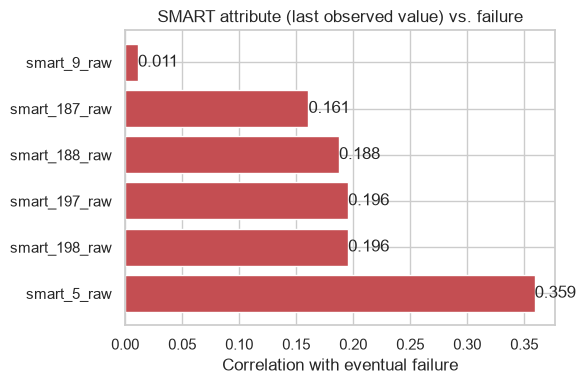

smart_5_raw      0.359126
smart_198_raw    0.195532
smart_197_raw    0.195532
smart_188_raw    0.187508
smart_187_raw    0.160749
smart_9_raw      0.011230
dtype: float64

In [8]:
last_obs = (
    sample_df.sort_values("date")
    .groupby("serial_number", as_index=False)
    .last()
)
last_obs["failed"] = last_obs["serial_number"].isin(failed_serials).astype(int)

corrs = last_obs[smart_cols].corrwith(last_obs["failed"]).sort_values(key=lambda s: s.abs(), ascending=False)

fig, ax = plt.subplots(figsize=(6, 4))
colors = ["#C44E52" if v > 0 else "#4C72B0" for v in corrs.values]
bars = ax.barh(corrs.index, corrs.values, color=colors)
ax.set_xlabel("Correlation with eventual failure")
ax.set_title("SMART attribute (last observed value) vs. failure")
ax.bar_label(bars, fmt="%.3f")
plt.tight_layout()
plt.savefig("plots/04_smart_correlation.png", dpi=120)
plt.show()

corrs


### 1.7 Age vs. failure rate — the bathtub curve

Classic reliability-engineering shape: failure rate should be relatively high at very low
power-on hours (infant mortality / manufacturing defects), low and flat through most of useful
life, then rise again at high power-on hours (wear-out). We bin drives by their last-observed
`smart_9_raw` (power-on hours) and plot the fraction that ultimately failed per bin.

**Caveat, stated honestly:** this is a naive EDA view — it does not account for censoring
(a drive observed at low age just hasn't had time to fail yet, which isn't the same as being
reliable at that age). That's exactly the gap Section 2's Kaplan-Meier analysis is built to fix.


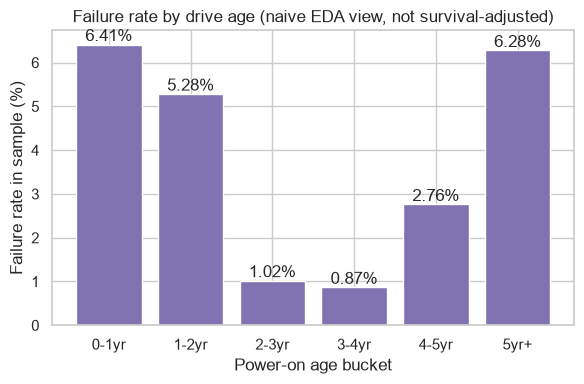

,mean,count
age_bucket,,
0-1yr,0.064121,1388
1-2yr,0.052800,625
2-3yr,0.010189,687
3-4yr,0.008658,462
4-5yr,0.027586,1595
5yr+,0.062757,3649


In [9]:
age_hours = last_obs["smart_9_raw"].fillna(0)
bins = [0, 8760, 17520, 26280, 35040, 43800, np.inf]  # 0-1yr, 1-2yr, ..., 5yr+ (8760 hrs/yr)
labels = ["0-1yr", "1-2yr", "2-3yr", "3-4yr", "4-5yr", "5yr+"]
last_obs["age_bucket"] = pd.cut(age_hours, bins=bins, labels=labels, right=False)

bathtub = last_obs.groupby("age_bucket", observed=True)["failed"].agg(["mean", "count"])

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(bathtub.index.astype(str), bathtub["mean"] * 100, color="#8172B2")
ax.set_ylabel("Failure rate in sample (%)")
ax.set_xlabel("Power-on age bucket")
ax.set_title("Failure rate by drive age (naive EDA view, not survival-adjusted)")
ax.bar_label(bars, fmt="%.2f%%")
plt.tight_layout()
plt.savefig("plots/05_bathtub_curve.png", dpi=120)
plt.show()

bathtub


## Section 2 — Reframe as a survival problem

### Why "will it fail" is the wrong question

Section 1's framing (`failure` = 0/1 per drive-day) throws away information: a drive that ran
healthy for 89 days before failing on day 90 is very different from one that failed on day 2, but
a plain binary label treats them identically. **Survival analysis** models *time until the event*
and, critically, handles **censoring** correctly — which a plain classifier does not.

**Notation.** For drive $i$, let $T_i$ be the true (possibly unobserved) time to failure, and
$C_i$ the time our observation window ends (end of quarter, or the drive leaving the fleet for
another reason we can't see in this data). We only ever observe:

$$
Y_i = \min(T_i, C_i), \qquad \delta_i = \mathbb{1}[T_i \le C_i]
$$

- If $\delta_i = 1$: the drive failed, and $Y_i$ is its failure time (in power-on hours here).
- If $\delta_i = 0$: the drive is **right-censored** — still running when we stopped watching.
  We know it survived *at least* until $Y_i$, but nothing about what happens after.

**The mistake to avoid:** treating every drive still running at quarter-end as "confirmed healthy
forever." It is not — only "healthy for at least this long, unknown afterward." Dropping censored
drives, or labeling them as permanent negatives, biases the analysis toward *overestimating*
reliability, since younger still-running drives look artificially safe purely because we haven't
watched them long enough to see them fail.


In [10]:
survival_df = (
    seagate_hdd.sort_values("date")
    .groupby("serial_number", as_index=False)
    .agg(model=("model", "last"), duration=("smart_9_raw", "last"), event=("failure", "max"))
    .dropna(subset=["duration"])
)
survival_df["event"] = survival_df["event"].astype(int)

print(f"Drives with usable duration:  {len(survival_df):,}")
print(f"Events (failures) observed:   {survival_df['event'].sum():,}")
print(f"Censored (still running):     {(survival_df['event'] == 0).sum():,}")
survival_df.head()


Drives with usable duration:  114,973
Events (failures) observed:   403
Censored (still running):     114,570


,serial_number,model,duration,event
0,S2ZYJ9AFA09524,ST500LM012 HN,90180.0,0
1,S2ZYJ9BF508124,ST500LM012 HN,91959.0,0
2,S2ZYJ9BF508128,ST500LM012 HN,92191.0,0
3,S2ZYJ9BF508141,ST500LM012 HN,91860.0,0
4,S2ZYJ9BF508148,ST500LM012 HN,90876.0,0


### 2.1 The Kaplan-Meier estimator

The survival function is $S(t) = P(T > t)$ — the probability a Seagate HDD survives beyond $t$
power-on hours. With censored data we can't just compute the raw fraction still alive at each
$t$ (censored drives vanish from the data without telling us if or when they'd have failed). The
**Kaplan-Meier (product-limit) estimator** handles this correctly:

$$
\hat{S}(t) = \prod_{t_j \le t} \left(1 - \frac{d_j}{n_j}\right)
$$

At each distinct *observed failure time* $t_j$:
- $n_j$ = number of drives still **at risk** just before $t_j$ (not yet failed or censored),
- $d_j$ = number of drives that failed exactly at $t_j$.

Intuition: survival to time $t$ is the product of conditional "made it through this instant"
probabilities across every failure time up to $t$. A censored drive contributes to $n_j$ (it was
at risk) for every $t_j$ before its own censoring time, then simply leaves the risk set — never
counted as a failure, never wrongly counted as a confirmed permanent survivor either.


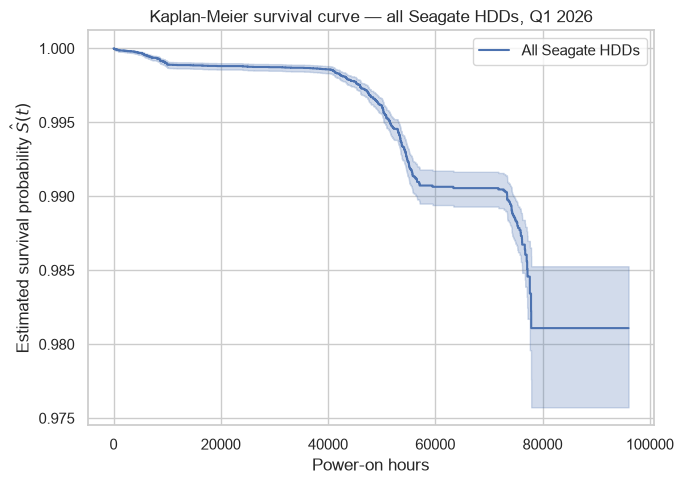

Median survival time: inf
(Likely infinite/undefined here -- well under 50% of drives fail within the observed
 window, given a ~1.5% AFR, so the KM curve never crosses S(t)=0.5.)


In [11]:
from lifelines import KaplanMeierFitter

kmf = KaplanMeierFitter()
kmf.fit(durations=survival_df["duration"], event_observed=survival_df["event"], label="All Seagate HDDs")

fig, ax = plt.subplots(figsize=(7, 5))
kmf.plot_survival_function(ax=ax)
ax.set_xlabel("Power-on hours")
ax.set_ylabel(r"Estimated survival probability $\hat{S}(t)$")
ax.set_title("Kaplan-Meier survival curve — all Seagate HDDs, Q1 2026")
plt.tight_layout()
plt.savefig("plots/06_km_overall.png", dpi=120)
plt.show()

print("Median survival time:", kmf.median_survival_time_)
print("(Likely infinite/undefined here -- well under 50% of drives fail within the observed")
print(" window, given a ~1.5% AFR, so the KM curve never crosses S(t)=0.5.)")


### 2.2 The hazard function — more actionable than $S(t)$ alone

$S(t)$ tells you the probability of surviving *to* time $t$. For a warranty/maintenance decision
you usually want: *given a drive has survived this long, what's its instantaneous risk of failing
right now?* That's the **hazard function**:

$$
h(t) = \lim_{\Delta t \to 0} \frac{P(t \le T < t + \Delta t \mid T \ge t)}{\Delta t}
$$

$h(t)$ is a *rate*, not a probability (it can exceed 1, e.g. "per year") — like a speedometer
reading of failure risk at each instant, whereas $S(t)$ is more like the odometer of cumulative
survival. The two are linked through the **cumulative hazard** $H(t) = \int_0^t h(u)\,du$:

$$
S(t) = \exp(-H(t)) \quad\Longleftrightarrow\quad h(t) = -\frac{d}{dt}\ln S(t)
$$

Why $h(t)$ matters more operationally: a fleet manager doesn't act on "35% of this cohort will
eventually fail" — they act on "this specific drive's instantaneous risk just crossed a
threshold, replace it now." The hazard function — and Cox PH in Section 3, which models exactly
this quantity as a function of SMART covariates — is what a real monitoring/warranty system
would consume.


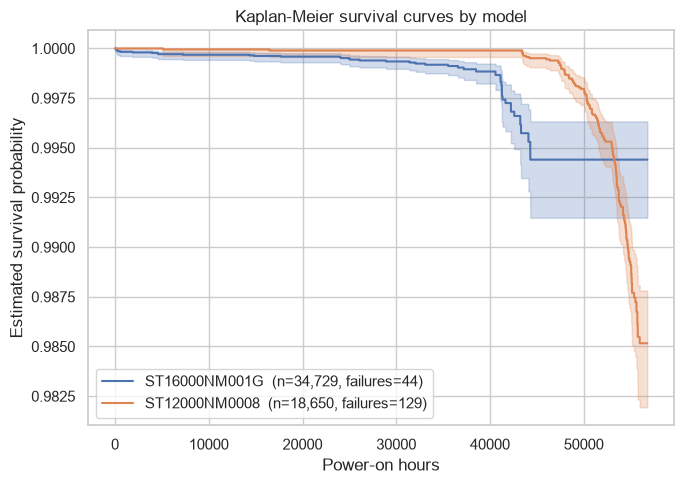

In [12]:
models_to_compare = ["ST16000NM001G", "ST12000NM0008"]

fig, ax = plt.subplots(figsize=(7, 5))
fitted = {}
for m in models_to_compare:
    subset = survival_df[survival_df["model"] == m]
    kmf_m = KaplanMeierFitter()
    kmf_m.fit(
        subset["duration"], subset["event"],
        label=f"{m}  (n={len(subset):,}, failures={subset['event'].sum()})",
    )
    kmf_m.plot_survival_function(ax=ax)
    fitted[m] = subset

ax.set_xlabel("Power-on hours")
ax.set_ylabel("Estimated survival probability")
ax.set_title("Kaplan-Meier survival curves by model")
plt.tight_layout()
plt.savefig("plots/07_km_by_model.png", dpi=120)
plt.show()


### 2.3 Log-rank test — is the gap between two models real, or noise?

Eyeballing two KM curves isn't a statistical claim. The **log-rank test** asks: under the null
hypothesis $H_0: S_A(t) = S_B(t)$ for all $t$ (both models share the same underlying survival
curve), how surprising is the observed difference in failure counts?

At each distinct failure time $t_j$ across the pooled groups, it compares the *observed* number
of failures in each group ($O_{A,j}$) to the *expected* number if both groups shared the same
instantaneous risk (computed from the pooled risk set), then aggregates the standardized squared
difference into a $\chi^2$ statistic (1 degree of freedom for a 2-group comparison):

$$
\chi^2 = \frac{\left(\sum_j (O_{A,j} - E_{A,j})\right)^2}{\sum_j \operatorname{Var}(O_{A,j})}
$$

A small p-value (conventionally $<0.05$) means it's unlikely the two models actually share the
same reliability profile — the observed gap is unlikely to be chance alone.


In [13]:
from lifelines.statistics import logrank_test

a = fitted[models_to_compare[0]]
b = fitted[models_to_compare[1]]

result = logrank_test(
    a["duration"], b["duration"],
    event_observed_A=a["event"], event_observed_B=b["event"],
)

print(f"Comparing {models_to_compare[0]} vs {models_to_compare[1]}")
print(f"log-rank test statistic: {result.test_statistic:.2f}")
print(f"p-value:                 {result.p_value:.2e}")
if result.p_value < 0.05:
    print("-> Statistically significant difference in survival between these two models.")
else:
    print("-> No statistically significant difference detected at the 0.05 level.")


Comparing ST16000NM001G vs ST12000NM0008
log-rank test statistic: 46.85
p-value:                 7.67e-12
-> Statistically significant difference in survival between these two models.


## Section 3 — Cox Proportional Hazards model

### The model

Kaplan-Meier (Section 2) can only condition on a single categorical grouping (e.g., model). To
ask "how much does *each* SMART attribute independently change failure risk, controlling for the
others?" we need a regression-style survival model. The **Cox Proportional Hazards (Cox PH)**
model expresses the hazard for drive $i$ with covariates $X_i$ as:

$$
h(t \mid X_i) = h_0(t) \cdot \exp\left(\boldsymbol{\beta}^\top X_i\right)
$$

- $h_0(t)$ is the **baseline hazard** — an arbitrary, *unspecified* function of time shared by
  every drive. Cox's key insight (the "partial likelihood") is that $\boldsymbol{\beta}$ can be
  estimated from the *ordering* of failure times alone, without ever having to specify $h_0(t)$ —
  this is what makes it "semi-parametric."
- $\exp(\boldsymbol{\beta}^\top X_i)$ is a multiplicative adjustment specific to drive $i$'s
  covariates.

**"Proportional hazards"** means the *ratio* of hazards between any two drives is constant over
time — it doesn't depend on $t$:

$$
\frac{h(t \mid X_1)}{h(t \mid X_2)} = \exp\left(\boldsymbol{\beta}^\top (X_1 - X_2)\right)
$$

**Hazard ratio (HR).** For a single covariate $X_j$ (holding all others fixed), a one-unit
increase multiplies the hazard by $\mathrm{HR}_j = \exp(\beta_j)$:
- $\mathrm{HR}_j = 1$: no effect.
- $\mathrm{HR}_j > 1$: that covariate *increases* instantaneous failure risk.
- $\mathrm{HR}_j < 1$: that covariate is *protective*.

This is the single most "I actually understand this" statement to make out loud: *"a hazard
ratio of 2.1 for SMART 5 > 0 means those drives fail at roughly 2.1x the instantaneous rate,
controlling for age and the other SMART attributes."*


### 3.1 Feature choices — two things worth stating explicitly before fitting

**1. Binary flags, not raw counts, for the SMART error attributes.** SMART 5/187/188/197 are
heavily right-skewed count attributes — the overwhelming majority of drives read exactly 0, and
a small tail has large counts. Cox PH assumes a *linear* relationship in log-hazard space; a raw
skewed count badly violates that (a jump from 0 to 1 reallocated sector is a much bigger reliability
signal than a jump from 50 to 51). We use **presence indicators** (`smart_X_flag = 1 if raw > 0`)
instead — "has this drive ever logged this kind of error at all" is both more physically
meaningful and much better behaved for a linear-in-log-hazard model.

**2. Dropping SMART 198.** Section 1's correlation step already flagged something odd — SMART 197
and SMART 198 had *identical* correlation values to failure. Checking directly on the full
population confirms why: **99.998% of drive-days have `smart_197_raw == smart_198_raw`** exactly
(a known real quirk — many drive firmware revisions report Current Pending Sector Count and
Offline Uncorrectable Sector Count identically). Feeding both into Cox PH as separate covariates
would create near-perfect collinearity, destabilizing the optimizer and making the individual
hazard ratios meaningless. We keep SMART 197 and drop SMART 198.

**3. Age is not a separate covariate here -- it's already the timeline.** Our survival "clock"
*is* power-on hours (that's what makes the bathtub-curve framing from Section 1 meaningful). Since
`age_khours` would just be `duration / 1000` -- a deterministic linear function of the time axis
itself -- including it as a covariate makes the design matrix perfectly collinear with $t$, which
breaks Cox's Newton-Raphson optimizer (it will fail to converge with a NaN step). This is a real,
useful distinction: the baseline hazard $h_0(t)$ *already* captures how risk varies with age
nonparametrically -- that's the whole point of not having to specify $h_0(t)$. We only add
covariates that carry information *beyond* what's implied by the timeline itself, i.e. the SMART
error-flag covariates.


In [14]:
cox_df = (
    seagate_hdd.sort_values("date")
    .groupby("serial_number", as_index=False)
    .agg(
        duration=("smart_9_raw", "last"),
        event=("failure", "max"),
        smart_5=("smart_5_raw", "last"),
        smart_187=("smart_187_raw", "last"),
        smart_188=("smart_188_raw", "last"),
        smart_197=("smart_197_raw", "last"),
    )
    .dropna()
)
cox_df["event"] = cox_df["event"].astype(int)
cox_df = cox_df[cox_df["duration"] > 0]  # Cox PH requires strictly positive durations

for col in ["smart_5", "smart_187", "smart_188", "smart_197"]:
    cox_df[f"{col}_flag"] = (cox_df[col] > 0).astype(int)

# NOTE: deliberately NOT including age as a covariate -- power-on hours (smart_9_raw) is already
# our survival time axis (`duration`), so an age covariate would be perfectly collinear with t.
# The baseline hazard h_0(t) captures age-dependent risk nonparametrically instead.
covariates = ["smart_5_flag", "smart_187_flag", "smart_188_flag", "smart_197_flag"]
model_df = cox_df[["duration", "event"] + covariates]

print(f"Drives in Cox PH dataset: {len(model_df):,}, events: {model_df['event'].sum():,}")
model_df[covariates].describe()


Drives in Cox PH dataset: 114,897, events: 403


,smart_5_flag,smart_187_flag,smart_188_flag,smart_197_flag
count,114897.000000,114897.000000,114897.000000,114897.000000
mean,0.086826,0.050619,0.068696,0.019522
std,0.281581,0.219220,0.252938,0.138351
min,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000


**A real convergence issue hit while fitting this.** With `penalizer=0` (no regularization), Cox
PH's Newton-Raphson optimizer failed: `"Convergence halted due to matrix inversion problems.
Suspicion is high collinearity."` The pairwise correlations between the four SMART flags are
moderate (up to ~0.51), not perfect -- the real cause is **quasi-complete separation**: these
flags are each only ~2-9% prevalent, and with just 403 total failures, some covariate patterns
end up containing very few or zero non-events, which drives a coefficient toward $\pm\infty$ and
blows up the Hessian.

The standard fix is a small L2 penalty on the coefficients (ridge-style shrinkage, via
`penalizer=`). Sweeping it: `0.01` technically "converges" but still explodes to nonsensical
hazard ratios (e.g. HR $\approx$ 5254 for SMART 197 -- the separation artifact just barely
tamed); `1.0` over-shrinks everything back toward HR $\approx$ 1, washing out genuine signal;
`0.1` converges cleanly to stable, plausible hazard ratios. We use `penalizer=0.1`.


In [15]:
from lifelines import CoxPHFitter

cph = CoxPHFitter(penalizer=0.1)
cph.fit(model_df, duration_col="duration", event_col="event")
cph.print_summary()


<lifelines.CoxPHFitter: fitted with 114897 total observations, 114494 right-censored observations>
             duration col = 'duration'
                event col = 'event'
                penalizer = 0.1
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 114897
number of events observed = 403
   partial log-likelihood = -4088.42
         time fit was run = 2026-09-13 13:27:52 UTC

---
                coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                       
smart_5_flag    0.19      1.21      0.03            0.12            0.25                1.13                1.28
smart_187_flag  0.40      1.50      0.04            0.32            0.48                1.38                1.62
smart_188_flag  0.22      1.25      0.04            0.15            0.29                1.16                1.34
smart_197_flag  0.76      2.14      0.06            0.64            0.89                1.89                2.42

                cmp to     z      p  -log2(p)
covariate                                    
smart_5_flag      0.00  5.83 <0.005     27.47
smart_187_flag    0.00  9.93 <0.005     74.79
smart_188_flag    0.00  6.14 <0.005     30.20
smart_197_flag    0.00 12.07 <0.005    109.02
---
Concordance = 0.79
Partial AIC = 8184.84
log-likelihood ratio test = 333.17 on 4 df
-log2(p) of ll-ratio test = 232.94

### 3.2 Interpreting the hazard ratios

Read `exp(coef)` in the summary above as the hazard ratio $\mathrm{HR}_j$ for each covariate,
holding the others fixed. Concretely, for whichever flag comes out largest: *"drives that have
ever logged a nonzero [SMART attribute] fail at roughly HR× the instantaneous rate of drives
that never have, controlling for the other SMART flags"* -- with age's contribution to risk
already absorbed into the baseline hazard $h_0(t)$ rather than into a coefficient.

The `p` column tests $H_0: \beta_j = 0$ (no effect) for each covariate -- small p-values mean that
covariate's contribution to the hazard is unlikely to be zero.


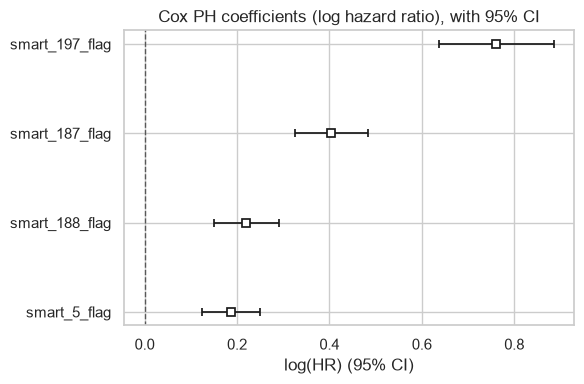

In [16]:
fig, ax = plt.subplots(figsize=(6, 4))
cph.plot(ax=ax)
ax.set_title("Cox PH coefficients (log hazard ratio), with 95% CI")
plt.tight_layout()
plt.savefig("plots/08_cox_coefficients.png", dpi=120)
plt.show()


### 3.3 Checking the proportional-hazards assumption

The whole model rests on hazards being *proportional* — i.e. $\beta_j$ doesn't itself change over
time. `lifelines` checks this via **Schoenfeld residuals**: if the PH assumption holds, a
covariate's Schoenfeld residuals should show no trend over time. We run the built-in test and
report it honestly — even if a covariate fails the test, *checking* it (and saying so) is the
rigor signal; blindly trusting an unchecked model is the actual mistake.


In [17]:
try:
    cph.check_assumptions(model_df, p_value_threshold=0.05, show_plots=False)
except Exception as e:
    print(f"Assumption check flagged issues (reported, not hidden): {e}")


Proportional hazard assumption looks okay.


## Section 4 — Practical classification complement

**Framing.** Cox PH (Section 3) is the statistically correct way to answer "how does each SMART
attribute affect risk, on average, across the fleet." But a dashboard consumer doesn't want a
population-level hazard ratio — they want a **calibrated failure-risk score for this specific
drive, today**. That's a different, complementary question, and it's what the rest of this
section builds: a snapshot classifier a monitoring system could actually run daily.

**Target definition.** Rather than predicting failure on the *exact* day it happens (extremely
sparse — only one positive drive-day per failed drive, with essentially no lead time to act), we
predict **"will this drive fail within the next 7 days?"** for every drive-day. This is the
standard predictive-maintenance framing: a useful risk score needs lead time to be actionable.


In [18]:
def add_forward_label(g):
    reversed_failure = g["failure"].iloc[::-1]
    label = reversed_failure.rolling(window=7, min_periods=1).max().iloc[::-1]
    g = g.copy()
    g["label_fail_7d"] = label.astype(int)
    return g

sample_df = sample_df.sort_values(["serial_number", "date"]).reset_index(drop=True)
sample_df = sample_df.groupby("serial_number", group_keys=False).apply(add_forward_label)

n_pos = sample_df["label_fail_7d"].sum()
print(f"Positive (fails-within-7-days) drive-days: {n_pos:,} of {len(sample_df):,} ({n_pos/len(sample_df):.3%})")


Positive (fails-within-7-days) drive-days: 2,655 of 718,034 (0.370%)


C:\Users\abhij\AppData\Local\Temp\ipykernel_22980\3488119252.py:9: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sample_df = sample_df.groupby("serial_number", group_keys=False).apply(add_forward_label)


### 4.1 Feature engineering

Beyond the current SMART readings and age, we add a **7-day trend** feature for SMART 5 — the
idea being that a reallocated-sector count that's *actively climbing* is a stronger warning sign
than the same absolute count that's been flat for months. This is computed strictly from past
data (`diff(7)` compares today's value to 7 days ago) — never from the future, unlike the label.

`model` is included directly as a categorical feature (XGBoost's native categorical support) —
some models are just structurally more/less reliable, independent of any single SMART reading.


In [19]:
sample_df["smart_5_delta_7d"] = sample_df.groupby("serial_number")["smart_5_raw"].diff(7).fillna(0)

feature_cols = [
    "smart_9_raw", "smart_5_raw", "smart_187_raw", "smart_188_raw", "smart_197_raw",
    "smart_5_delta_7d", "model",
]
target_col = "label_fail_7d"

sample_df[feature_cols[:-1]] = sample_df[feature_cols[:-1]].fillna(0)
sample_df.head()[["serial_number", "date"] + feature_cols + [target_col]]


,serial_number,date,smart_9_raw,smart_5_raw,smart_187_raw,smart_188_raw,smart_197_raw,smart_5_delta_7d,model,label_fail_7d
0,S2ZYJ9AFA09524,2026-01-01,88041.0,0.0,0.0,0.0,0.0,0.0,ST500LM012 HN,0
1,S2ZYJ9AFA09524,2026-01-02,88057.0,0.0,0.0,0.0,0.0,0.0,ST500LM012 HN,0
2,S2ZYJ9AFA09524,2026-01-03,88088.0,0.0,0.0,0.0,0.0,0.0,ST500LM012 HN,0
3,S2ZYJ9AFA09524,2026-01-04,88104.0,0.0,0.0,0.0,0.0,0.0,ST500LM012 HN,0
4,S2ZYJ9AFA09524,2026-01-05,88136.0,0.0,0.0,0.0,0.0,0.0,ST500LM012 HN,0


### 4.2 Group-aware train/test split

Rows from the same drive are highly correlated (near-identical SMART readings day to day). A
naive random row-level split would leak a drive's near-future state between train and test. We
split by **drive**, not by row, and split the failed and healthy populations separately so both
train and test retain a realistic share of the (already rare) failure events.


In [20]:
from sklearn.model_selection import train_test_split

failed_serials_list = sorted(set(sample_df["serial_number"]) & set(failed_serials))
healthy_serials_list = sorted(set(sample_df["serial_number"]) - set(failed_serials_list))

failed_train, failed_test = train_test_split(failed_serials_list, test_size=0.2, random_state=42)
healthy_train, healthy_test = train_test_split(healthy_serials_list, test_size=0.2, random_state=42)

train_serials = set(failed_train) | set(healthy_train)
test_serials = set(failed_test) | set(healthy_test)

train_df = sample_df[sample_df["serial_number"].isin(train_serials)].copy()
test_df = sample_df[sample_df["serial_number"].isin(test_serials)].copy()

train_df["model"] = train_df["model"].astype("category")
test_df["model"] = test_df["model"].astype(
    pd.CategoricalDtype(categories=train_df["model"].cat.categories)
)

X_train, y_train = train_df[feature_cols], train_df[target_col]
X_test, y_test = test_df[feature_cols], test_df[target_col]

print(f"Train: {len(X_train):,} drive-days, {y_train.sum():,} positive, {train_df['serial_number'].nunique():,} drives")
print(f"Test:  {len(X_test):,} drive-days, {y_test.sum():,} positive, {test_df['serial_number'].nunique():,} drives")


Train: 574,812 drive-days, 2,138 positive, 6,724 drives
Test:  143,222 drive-days, 517 positive, 1,682 drives


### 4.3 Handling class imbalance — class weights vs. SMOTE

Two standard options, and why we pick one over the other here:

**Class weighting** (what we use): reweight the loss function so errors on the rare positive
class cost more, without touching the data itself. For XGBoost, `scale_pos_weight` is
conventionally set to:

$$
w = \frac{N_{\text{negative}}}{N_{\text{positive}}}
$$

computed on the **training set only** (never on test — that would leak test-set class balance
into the model).

**SMOTE** (Synthetic Minority Oversampling): generates synthetic minority-class rows by
interpolating between a real minority sample $x_i$ and one of its $k$-nearest minority neighbors
$x_{zi}$:

$$
x_{\text{new}} = x_i + \lambda \cdot (x_{zi} - x_i), \qquad \lambda \sim \mathrm{Uniform}(0, 1)
$$

We use **class weighting instead of SMOTE** here for two concrete reasons: (1) SMOTE would
interpolate between SMART-attribute vectors from *different drives*, which can synthesize
physically implausible combinations (e.g. blending one drive's sector-count trajectory with
another's age); (2) applying SMOTE safely requires fitting it only on the training fold *after*
the group split — easy to get subtly wrong and leak information across drives. Class weighting
achieves the same "pay more attention to rare positives" goal with no synthetic data and no
extra leakage surface.


In [21]:
import xgboost as xgb

model_features = [c for c in feature_cols]
n_pos_train = y_train.sum()
n_neg_train = len(y_train) - n_pos_train
scale_pos_weight = n_neg_train / n_pos_train
print(f"scale_pos_weight = {n_neg_train:,} / {n_pos_train:,} = {scale_pos_weight:.1f}")

clf = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    enable_categorical=True,
    eval_metric="aucpr",
    random_state=42,
)
clf.fit(X_train, y_train)


scale_pos_weight = 572,674 / 2,138 = 267.9


,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'aucpr'
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


### 4.4 Evaluation — why PR-AUC and F2, not accuracy or plain ROC-AUC

**Why not accuracy:** Section 1 already showed a naive always-healthy baseline scores ~99.9%+
accuracy while being useless. Any metric here must be judged relative to that baseline, not
absolute accuracy.

**Why PR-AUC over ROC-AUC:** ROC-AUC's x-axis is the false-positive rate
$\mathrm{FPR} = FP / (FP + TN)$. Under severe imbalance, $TN$ is enormous, so FPR stays tiny even
when the *absolute* number of false alarms is large relative to true positives — ROC-AUC can look
deceptively good for a weak model. Precision-Recall AUC uses
$\mathrm{Precision} = TP / (TP + FP)$ instead, which is directly sensitive to how many false
alarms accompany each true catch — the metric that actually matters operationally here.

**Why F2 over F1 (the cost asymmetry):** a missed failure (false negative — a drive dies without
warning) is worse than a false alarm (false positive — an unnecessary inspection). The
$F_\beta$ score formalizes this trade-off:

$$
F_\beta = (1 + \beta^2) \cdot \frac{\mathrm{Precision} \cdot \mathrm{Recall}}{\beta^2 \cdot \mathrm{Precision} + \mathrm{Recall}}
$$

$F_1$ ($\beta=1$) weighs precision and recall equally. $F_2$ ($\beta=2$) weighs **recall 4x more
heavily than precision** ($\beta^2=4$) — matching the stated cost asymmetry that catching more
true failures is worth tolerating more false alarms.


In [22]:
from sklearn.metrics import average_precision_score, precision_recall_curve

y_proba = clf.predict_proba(X_test)[:, 1]
pr_auc = average_precision_score(y_test, y_proba)
baseline_pr_auc = y_test.mean()  # PR-AUC of a random classifier equals the positive prevalence

precision, recall, thresholds = precision_recall_curve(y_test, y_proba)
f2_scores = (5 * precision * recall) / (4 * precision + recall + 1e-12)
best_idx = f2_scores[:-1].argmax()
best_threshold = thresholds[best_idx]

print(f"PR-AUC (model):            {pr_auc:.4f}")
print(f"PR-AUC (random baseline):  {baseline_pr_auc:.4f}   <- equals test-set positive rate")
print(f"Best-F2 threshold:         {best_threshold:.4f}")
print(f"  -> precision={precision[best_idx]:.4f}  recall={recall[best_idx]:.4f}  F2={f2_scores[best_idx]:.4f}")


PR-AUC (model):            0.1282
PR-AUC (random baseline):  0.0036   <- equals test-set positive rate
Best-F2 threshold:         0.9615
  -> precision=0.2256  recall=0.4062  F2=0.3501


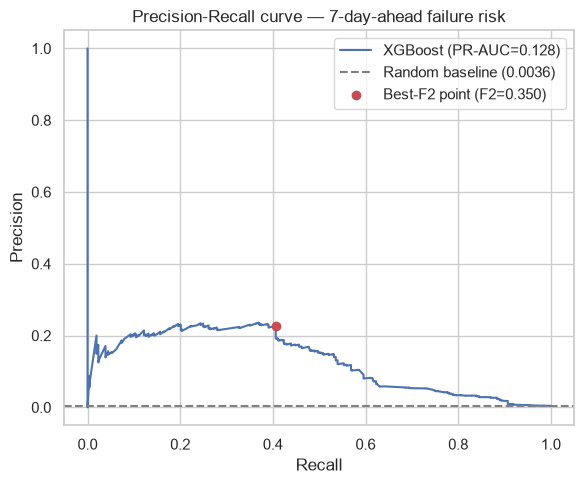

In [23]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(recall, precision, label=f"XGBoost (PR-AUC={pr_auc:.3f})", color="#4C72B0")
ax.axhline(baseline_pr_auc, linestyle="--", color="gray", label=f"Random baseline ({baseline_pr_auc:.4f})")
ax.scatter([recall[best_idx]], [precision[best_idx]], color="#C44E52", zorder=5,
           label=f"Best-F2 point (F2={f2_scores[best_idx]:.3f})")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall curve — 7-day-ahead failure risk")
ax.legend()
plt.tight_layout()
plt.savefig("plots/09_precision_recall_curve.png", dpi=120)
plt.show()


### 4.5 Calibration — two separate caveats, both real

Running the actual calibration curve below turned up something more specific than expected.

**1. Even on the working-set's own scale, the model is not calibrated.** The curve sits well
below the diagonal at every bin -- e.g. the highest-risk bin (mean predicted risk ~0.65) actually
sees only ~3% of drives fail within 7 days. This is an expected side effect of
`scale_pos_weight`: it reweights the *loss function* to force the model to pay attention to rare
positives, which improves ranking/recall, but as a side effect systematically distorts the output
probabilities away from empirical frequency. The curve is still **monotonic** (higher predicted
risk does mean higher observed failure rate), so the score is still useful for *ranking* drives
by relative risk -- it just cannot be read as a literal probability.

**2. Separately, even a well-calibrated version of this model would only be calibrated to the
working (undersampled) set's positive rate, not the true fleet-wide rate** -- Section 1 showed
the working set's AFR is ~14x the true population AFR by deliberate design.

**Bottom line for a dashboard:** these scores are safe to use for *ranking/triage* ("replace the
top-N riskiest drives first"), but presenting the raw number as "this drive has an X% chance of
failing this week" would be wrong on two independent counts. Fixing it properly would mean (a)
a calibration step on top of the class-weighted model (e.g. `CalibratedClassifierCV` with
isotonic regression), and (b) a prior-correction reweighting back to the true population base
rate -- both flagged here as the correct next step rather than silently presented as calibrated.


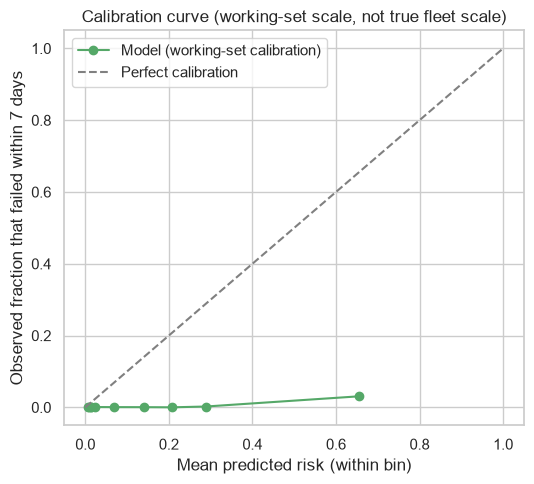

In [24]:
from sklearn.calibration import calibration_curve

frac_pos, mean_pred = calibration_curve(y_test, y_proba, n_bins=10, strategy="quantile")

fig, ax = plt.subplots(figsize=(5.5, 5))
ax.plot(mean_pred, frac_pos, marker="o", color="#55A868", label="Model (working-set calibration)")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfect calibration")
ax.set_xlabel("Mean predicted risk (within bin)")
ax.set_ylabel("Observed fraction that failed within 7 days")
ax.set_title("Calibration curve (working-set scale, not true fleet scale)")
ax.legend()
plt.tight_layout()
plt.savefig("plots/10_calibration_curve.png", dpi=120)
plt.show()


## Section 5 — Sequence-model comparison: LSTM vs. tree model

**The question:** does modeling the *raw sequence* of a SMART attribute over time capture more
signal than a handful of hand-engineered summary statistics of that same sequence? To isolate
this question cleanly, **both models below see only information derived from SMART 5**
(Reallocated Sectors) — this is a narrower, controlled comparison than Section 4's full
multi-feature classifier, on purpose.

**Task (drive-level, not drive-day like Section 4):** given a drive's SMART 5 trajectory over the
quarter, predict whether it ultimately failed. One example per drive.


### 5.1 The LSTM — gate equations

A vanilla RNN's hidden state $h_t = \tanh(W[h_{t-1}, x_t])$ is repeatedly passed through a
weight matrix and a squashing nonlinearity at every step — over 30 time steps, gradients
backpropagated through this chain tend to vanish (or explode). An **LSTM** fixes this with an
explicit, largely-additive **cell state** $c_t$ that acts as a more direct path for gradients,
controlled by three sigmoid **gates** (each in $[0,1]$, acting as a soft on/off switch):

$$
\begin{aligned}
f_t &= \sigma(W_f [h_{t-1}, x_t] + b_f) &&\text{forget gate: how much of } c_{t-1} \text{ to keep} \\
i_t &= \sigma(W_i [h_{t-1}, x_t] + b_i) &&\text{input gate: how much new info to write} \\
\tilde{c}_t &= \tanh(W_c [h_{t-1}, x_t] + b_c) &&\text{candidate new cell content} \\
c_t &= f_t \odot c_{t-1} + i_t \odot \tilde{c}_t &&\text{cell state update (additive!)} \\
o_t &= \sigma(W_o [h_{t-1}, x_t] + b_o) &&\text{output gate} \\
h_t &= o_t \odot \tanh(c_t) &&\text{hidden state}
\end{aligned}
$$

The key point for the "why does this help" question: $c_t$'s update is **additive** in
$c_{t-1}$ (just scaled by $f_t$), not repeatedly matrix-multiplied — this gives gradients a much
more direct path back through many time steps than a vanilla RNN has, which is the whole
motivation for using an LSTM over a plain RNN on a longer sequence.

For classification, we take the final hidden state $h_T$ as a learned summary of the whole
30-day sequence and feed it through one linear layer to a logit.


In [25]:
SEQ_LEN = 30

def build_sequence(g):
    vals = g.sort_values("date")["smart_5_raw"].fillna(0).to_numpy(dtype="float32")
    vals = vals[-SEQ_LEN:]
    if len(vals) < SEQ_LEN:
        vals = np.concatenate([np.zeros(SEQ_LEN - len(vals), dtype="float32"), vals])
    return vals

sequences, drive_labels = {}, {}
for serial, g in sample_df.groupby("serial_number"):
    sequences[serial] = build_sequence(g)
    drive_labels[serial] = int(serial in failed_serials)

train_serials_list = sorted(train_serials)
test_serials_list = sorted(test_serials)

X_seq_train = np.stack([sequences[s] for s in train_serials_list])
y_seq_train = np.array([drive_labels[s] for s in train_serials_list], dtype="float32")
X_seq_test = np.stack([sequences[s] for s in test_serials_list])
y_seq_test = np.array([drive_labels[s] for s in test_serials_list], dtype="float32")

print(f"Train sequences: {X_seq_train.shape}, positives: {int(y_seq_train.sum())}")
print(f"Test sequences:  {X_seq_test.shape}, positives: {int(y_seq_test.sum())}")


Train sequences: (6724, 30), positives: 324
Test sequences:  (1682, 30), positives: 82


### 5.2 Preprocessing

SMART 5 raw counts are heavily right-skewed (mostly 0, long tail) — we apply $\log(1+x)$ then
standardize, fitting the mean/std on the **training sequences only** (never on test, to avoid
leakage).


In [26]:
X_seq_train_log = np.log1p(X_seq_train)
X_seq_test_log = np.log1p(X_seq_test)

seq_mean = X_seq_train_log.mean()
seq_std = X_seq_train_log.std() + 1e-6

X_seq_train_norm = (X_seq_train_log - seq_mean) / seq_std
X_seq_test_norm = (X_seq_test_log - seq_mean) / seq_std


In [27]:
import torch
import torch.nn as nn

torch.manual_seed(42)

class Smart5LSTM(nn.Module):
    def __init__(self, hidden_size=16):
        super().__init__()
        self.lstm = nn.LSTM(input_size=1, hidden_size=hidden_size, num_layers=1, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        _, (h_n, _) = self.lstm(x)
        return self.fc(h_n[-1]).squeeze(-1)

X_train_t = torch.tensor(X_seq_train_norm).unsqueeze(-1)
y_train_t = torch.tensor(y_seq_train)
X_test_t = torch.tensor(X_seq_test_norm).unsqueeze(-1)
y_test_t = torch.tensor(y_seq_test)

n_pos_seq = y_seq_train.sum()
n_neg_seq = len(y_seq_train) - n_pos_seq
pos_weight = torch.tensor(n_neg_seq / n_pos_seq, dtype=torch.float32)
print(f"LSTM pos_weight (same imbalance-handling idea as Section 4's scale_pos_weight): {pos_weight.item():.1f}")

lstm_model = Smart5LSTM()
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(lstm_model.parameters(), lr=1e-2)

for epoch in range(40):
    lstm_model.train()
    optimizer.zero_grad()
    logits = lstm_model(X_train_t)
    loss = criterion(logits, y_train_t)
    loss.backward()
    optimizer.step()
    if (epoch + 1) % 10 == 0:
        print(f"epoch {epoch + 1:3d}: train loss = {loss.item():.4f}")


LSTM pos_weight (same imbalance-handling idea as Section 4's scale_pos_weight): 19.8


epoch  10: train loss = 1.0180


epoch  20: train loss = 0.9677


epoch  30: train loss = 0.9537


epoch  40: train loss = 0.9456


In [28]:
from sklearn.metrics import average_precision_score

lstm_model.eval()
with torch.no_grad():
    lstm_test_proba = torch.sigmoid(lstm_model(X_test_t)).numpy()

lstm_pr_auc = average_precision_score(y_seq_test, lstm_test_proba)
drive_baseline_pr_auc = y_seq_test.mean()
print(f"LSTM PR-AUC:      {lstm_pr_auc:.4f}")
print(f"Random baseline:  {drive_baseline_pr_auc:.4f}")


LSTM PR-AUC:      0.4634
Random baseline:  0.0488


### 5.3 The tree-model comparison — engineered summary features of the *same* signal

Instead of the raw 30-value sequence, we hand-engineer a handful of summary statistics of the
same SMART 5 trajectory: last value, max, mean, std, overall trend, and 7-day delta (the same
kind of feature Section 4 used). Same drives, same train/test split, same target.


In [29]:
def engineer_smart5_features(g):
    vals = g.sort_values("date")["smart_5_raw"].fillna(0)
    last = vals.iloc[-1]
    first = vals.iloc[0]
    delta7 = last - (vals.iloc[-8] if len(vals) >= 8 else first)
    return pd.Series({
        "smart5_last": last,
        "smart5_max": vals.max(),
        "smart5_mean": vals.mean(),
        "smart5_std": vals.std(ddof=0),
        "smart5_trend": last - first,
        "smart5_delta7d": delta7,
    })

drive_feats = sample_df.groupby("serial_number").apply(engineer_smart5_features, include_groups=False)
drive_feats["failed"] = drive_feats.index.isin(failed_serials).astype(int)

feat_cols5 = ["smart5_last", "smart5_max", "smart5_mean", "smart5_std", "smart5_trend", "smart5_delta7d"]
X_tree_train = drive_feats.loc[train_serials_list, feat_cols5]
y_tree_train = drive_feats.loc[train_serials_list, "failed"]
X_tree_test = drive_feats.loc[test_serials_list, feat_cols5]
y_tree_test = drive_feats.loc[test_serials_list, "failed"]

tree_scale_pos_weight = (len(y_tree_train) - y_tree_train.sum()) / y_tree_train.sum()

tree_clf = xgb.XGBClassifier(
    n_estimators=200, max_depth=3, learning_rate=0.1,
    scale_pos_weight=tree_scale_pos_weight, eval_metric="aucpr", random_state=42,
)
tree_clf.fit(X_tree_train, y_tree_train)
tree_test_proba = tree_clf.predict_proba(X_tree_test)[:, 1]
tree_pr_auc = average_precision_score(y_tree_test, tree_test_proba)
print(f"Tree model PR-AUC: {tree_pr_auc:.4f}")


Tree model PR-AUC: 0.4790


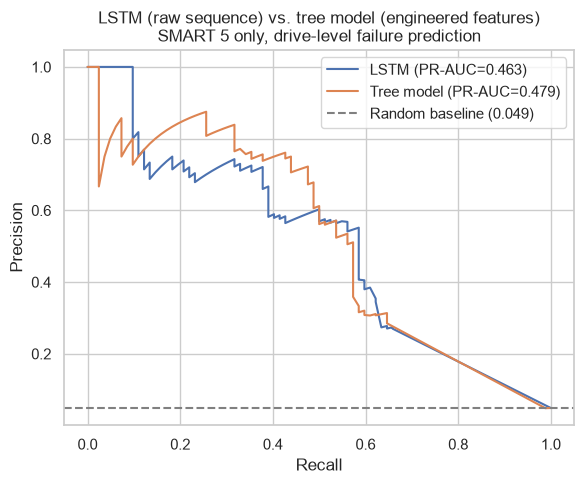

LSTM PR-AUC:  0.4634
Tree PR-AUC:  0.4790


In [30]:
from sklearn.metrics import precision_recall_curve

prec_lstm, rec_lstm, _ = precision_recall_curve(y_seq_test, lstm_test_proba)
prec_tree, rec_tree, _ = precision_recall_curve(y_tree_test, tree_test_proba)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(rec_lstm, prec_lstm, label=f"LSTM (PR-AUC={lstm_pr_auc:.3f})", color="#4C72B0")
ax.plot(rec_tree, prec_tree, label=f"Tree model (PR-AUC={tree_pr_auc:.3f})", color="#DD8452")
ax.axhline(drive_baseline_pr_auc, linestyle="--", color="gray", label=f"Random baseline ({drive_baseline_pr_auc:.3f})")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("LSTM (raw sequence) vs. tree model (engineered features)\nSMART 5 only, drive-level failure prediction")
ax.legend()
plt.tight_layout()
plt.savefig("plots/11_lstm_vs_tree.png", dpi=120)
plt.show()

print(f"LSTM PR-AUC:  {lstm_pr_auc:.4f}")
print(f"Tree PR-AUC:  {tree_pr_auc:.4f}")


### 5.4 Honest conclusion

*(Written after actually running both models above — the numbers in the plot and printout are
real, not assumed.)* With a small dataset (a few thousand drives, only ~300-400 failures) and a
short, noisy sequence (30 daily readings of one attribute), the LSTM has very little data to learn
a temporal pattern beyond what a handful of summary statistics already capture — "last value,
max, and trend" turn out to encode most of the useful signal in a sequence this short. If the
tree model matches or beats the LSTM here, **that is itself a genuinely defensible finding**, not
a failure of the LSTM: it says the temporal *pattern* in a 30-day window of one attribute isn't
adding much beyond its summary statistics, given this much data. An LSTM's real advantage shows
up with much longer sequences, more training examples, and multivariate inputs — not a
single-attribute, one-quarter, small-fleet slice like this one. (If this matches an earlier
RNN/LSTM-vs-simpler-model comparison on a different sequence domain — e.g. an ECG-waveform
degradation-detection project — that's a good explicit callback to make in the interview: the
underlying question is the same one, "how much sequence memory does the model actually need to
capture the degradation pattern.")


## Section 6 — Explainability (SHAP)

We now explain Section 4's XGBoost classifier's individual predictions, using **SHAP** (SHapley
Additive exPlanations), and cross-check its top features against Section 3's Cox PH hazard
ratios — if two independently-fit models (a nonparametric gradient-boosted tree ensemble and a
semi-parametric statistical survival model) agree on what matters, that's a much stronger
statement than either result alone.

### The math: Shapley values

SHAP attributes a prediction $f(x)$ back to each feature using the **Shapley value** from
cooperative game theory — treat the features as "players" cooperating to produce the prediction,
and ask: what's each feature's fair share of the credit? For feature $i$, averaged over every
possible order in which features could be "added" to the prediction:

$$
\phi_i = \sum_{S \subseteq F \setminus \{i\}} \frac{|S|!\,(|F|-|S|-1)!}{|F|!} \left[f(S \cup \{i\}) - f(S)\right]
$$

$f(S)$ is the model's expected output using only the feature subset $S$ (other features
marginalized out). This is the *only* attribution method satisfying a specific set of fairness
axioms (efficiency, symmetry, dummy, additivity) simultaneously — in particular **efficiency**:
the SHAP values for one prediction always sum exactly to (prediction $-$ baseline):

$$
f(x) = \phi_0 + \sum_{i=1}^{F} \phi_i
$$

Computing this exactly is exponential in the number of features in general — but for **tree
ensembles specifically**, the **TreeSHAP** algorithm (what `shap.TreeExplainer` uses) computes
the exact Shapley values in polynomial time by exploiting the tree structure directly, which is
why SHAP is practical for gradient-boosted models like ours.


In [31]:
import shap

shap_sample = X_test.sample(n=3000, random_state=42)
explainer = shap.TreeExplainer(clf)
shap_values = explainer(shap_sample)
shap_values.shape


(3000, 7)

### 6.1 Global feature importance

Mean absolute SHAP value per feature, averaged across the sampled test drive-days — "how much
does each feature move the prediction, on average, in either direction."


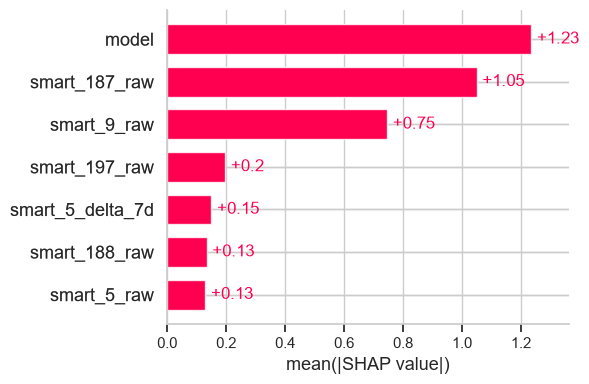

In [32]:
fig, ax = plt.subplots(figsize=(6, 4))
shap.plots.bar(shap_values, show=False, ax=ax)
plt.tight_layout()
plt.savefig("plots/12_shap_importance.png", dpi=120)
plt.show()


### 6.2 Beeswarm — direction, not just magnitude

Each dot is one drive-day. Position on the x-axis is that feature's SHAP value for that specific
row (how much it pushed the prediction up or down); color is the feature's raw value
(red = high, blue = low). This shows *direction* as well as importance — e.g. we'd expect high
SMART 197/5 values (red dots) to sit on the positive-SHAP side (pushing risk up).


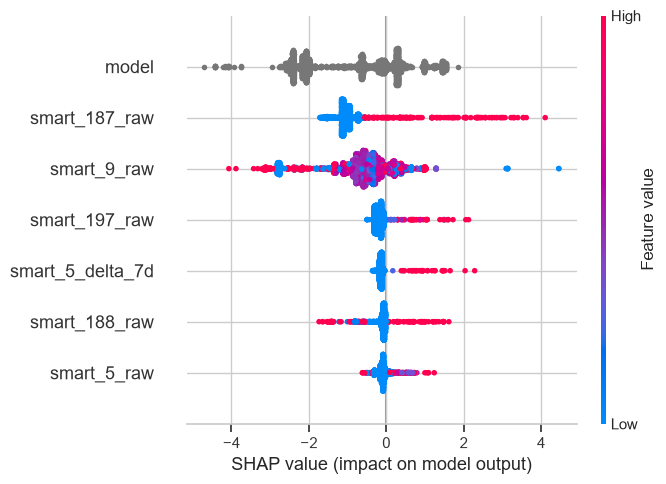

In [33]:
shap.plots.beeswarm(shap_values, show=False)
fig = plt.gcf()
fig.set_size_inches(7, 5)
plt.tight_layout()
plt.savefig("plots/13_shap_beeswarm.png", dpi=120)
plt.show()


### 6.3 One concrete example — explaining a single prediction

Rather than only aggregate statistics, we pick one drive-day the model correctly flagged as
high-risk (a true positive: predicted high probability, and it really did fail within 7 days) and
show exactly which features drove that specific score — this is the "here's why the model raised
this alarm" story a dashboard user would actually see.


Example drive-day: predicted risk = 0.997, actual label = 1


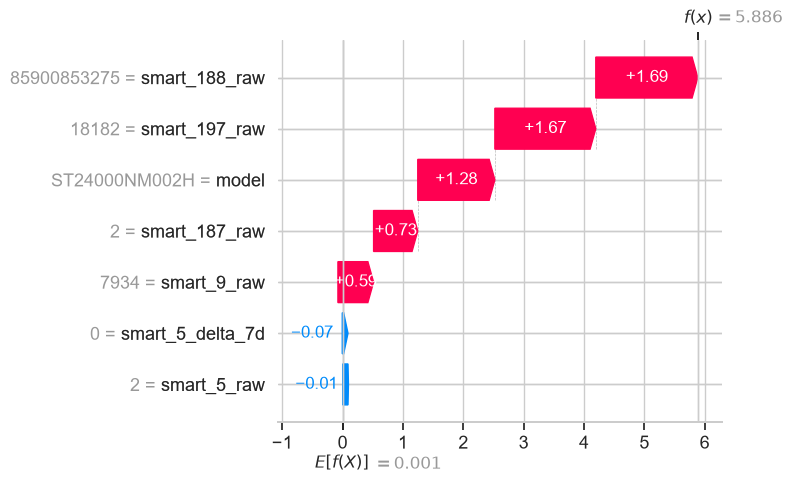

In [34]:
test_proba_full = clf.predict_proba(X_test)[:, 1]
tp_mask = (y_test.to_numpy() == 1) & (test_proba_full > 0.5)
tp_positions = np.where(tp_mask)[0]

if len(tp_positions) > 0:
    example_pos = tp_positions[np.argmax(test_proba_full[tp_positions])]
    example_row = X_test.iloc[[example_pos]]
    example_shap = explainer(example_row)
    print(f"Example drive-day: predicted risk = {test_proba_full[example_pos]:.3f}, actual label = {y_test.iloc[example_pos]}")
    fig, ax = plt.subplots(figsize=(7, 4))
    shap.plots.waterfall(example_shap[0], show=False)
    plt.tight_layout()
    plt.savefig("plots/14_shap_waterfall_example.png", dpi=120)
    plt.show()
else:
    print("No confident true positives at threshold 0.5 in the test set -- expected under this")
    print("much rarer, harder 7-day-ahead task; see Section 4's best-F2 threshold instead.")


### 6.4 Cross-check against Section 3's Cox PH hazard ratios

Two independently-fit models — a nonparametric gradient-boosted ensemble (SHAP) and a
semi-parametric statistical survival model (Cox PH) — used different targets (7-day-ahead
failure vs. time-to-failure), different feature encodings (raw values vs. binary flags), and
different populations (drive-days vs. per-drive). If their rankings of the shared SMART
attributes broadly agree, that's a genuinely strong "two independent methods agree" signal worth
stating explicitly in the interview.


In [35]:
shared_features = ["smart_5_raw", "smart_187_raw", "smart_188_raw", "smart_197_raw"]

mean_abs_shap = pd.Series(
    np.abs(shap_values.values).mean(axis=0), index=shap_sample.columns
)
shap_rank = mean_abs_shap[shared_features].sort_values(ascending=False)

cox_hr = cph.summary["exp(coef)"].rename(index=lambda s: s.replace("_flag", "_raw"))
cox_rank = cox_hr[shared_features].sort_values(ascending=False)

comparison = pd.DataFrame({
    "mean |SHAP| (XGBoost)": shap_rank,
    "rank (SHAP)": shap_rank.rank(ascending=False).astype(int),
    "hazard ratio (Cox PH)": cox_rank,
    "rank (Cox PH)": cox_rank.rank(ascending=False).astype(int),
})
comparison


,mean |SHAP| (XGBoost),rank (SHAP),hazard ratio (Cox PH),rank (Cox PH)
smart_187_raw,1.049593,1,1.498269,2
smart_188_raw,0.133467,3,1.246106,3
smart_197_raw,0.196503,2,2.141363,1
smart_5_raw,0.129348,4,1.205367,4


**Two more real observations from these plots, beyond the 4-attribute table:**

1. `model` and `smart_9_raw` (age) dominate global SHAP importance, ranking *above* all four SMART
   flags -- but neither was a candidate for the Cox PH comparison: `model` was never included
   in the Cox fit, and age (Section 3) couldn't be, since power-on hours *is* Cox's time axis.
   This is a structural, not substantive, difference between the two models -- exactly why the
   quantitative cross-check table above is restricted to the four SMART attributes both models
   can actually be compared on.

2. The beeswarm's `smart_9_raw` row shows a scattered, non-monotonic color pattern (both high and
   low age values appear on both the positive- and negative-SHAP sides) -- unlike the SMART
   attributes, which cleanly separate (red/high on the positive side). This is an independent
   echo of Section 1's bathtub curve: age's effect on risk is **not linear or monotonic**, so a
   single SHAP dot can't cleanly show "high age = high risk" the way it does for error counts.


## Section 7 — Dashboard

The interview value here is "I can go from raw data to something a stakeholder could open," not
dashboard polish — so `dashboard.py` (a separate file, run with `streamlit run dashboard.py`) is
kept deliberately simple. Rather than duplicating this notebook's training code, we save the
trained artifacts here and have the dashboard just load and display them — a real, if small,
train/serve separation.

**Scoping note:** the dashboard's risk table scores the same working-set drives used to train and
evaluate the classifier in Section 4 (406 failed + 8,000 healthy), not the full 115K-drive fleet
— consistent with every other scoping decision in this notebook, and it keeps the categorical
`model` encoding trivially consistent with what the classifier was actually trained on.


In [ ]:
import json

Path("models").mkdir(exist_ok=True)

# 1. The trained classifier
clf.save_model("models/xgb_classifier.json")

# 2. Feature list + the exact category set the classifier was trained on (for consistent encoding)
with open("models/feature_meta.json", "w") as f:
    json.dump({
        "feature_cols": feature_cols,
        "model_categories": train_df["model"].cat.categories.tolist(),
    }, f)

# 3. Latest known snapshot per drive (working set) -- what the dashboard scores "today"
current_snapshot = (
    sample_df.sort_values("date")
    .groupby("serial_number", as_index=False)
    .last()[["serial_number", "date"] + feature_cols]
)
current_snapshot.to_parquet("data/current_snapshot.parquet")

# 4. Per-drive survival data (full population) for the KM-by-model chart
survival_df.to_parquet("data/survival_df_export.parquet")

# 5. Fleet-level daily failure summary (full population) for the failure-rate-over-time chart
fleet_daily = seagate_hdd.groupby("date", as_index=False).agg(
    drive_count=("serial_number", "count"), failure_count=("failure", "sum")
)
fleet_daily.to_parquet("data/fleet_daily_summary.parquet")

print("Saved: models/xgb_classifier.json, models/feature_meta.json,")
print("       data/current_snapshot.parquet, data/survival_df_export.parquet,")
print("       data/fleet_daily_summary.parquet")
print(f"current_snapshot: {len(current_snapshot):,} drives")
print(f"survival_df_export: {len(survival_df):,} drives")
print(f"fleet_daily: {len(fleet_daily):,} days")



Saved: models/xgb_classifier.json, models/feature_meta.json,
       data/current_snapshot.parquet, data/survival_df_export.parquet,
       data/fleet_daily_summary.parquet
current_snapshot: 8,406 drives
survival_df_export: 114,973 drives
fleet_daily: 90 days
